# Distribution of Articles by Class (Camera-Ready)

This notebook reproduces and upgrades the class-distribution chart from `results.ipynb`
for publication use.

Design choices:
- no figure title,
- corrected indicator names,
- horizontal x labels,
- project-consistent serif typography,
- consistent class-color mapping (with lighter green for class `1`).


## 1) Imports and Style


In [16]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 12,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})


## 2) Configuration


In [17]:
PROJECT_ROOT = Path.cwd()

CANDIDATE_DATA_FILES = [
    PROJECT_ROOT / "outputs" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT / "sensitivity" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT / "Version 2" / "outputs" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT / "Version 2" / "sensitivity" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT.parent / "Version 2" / "outputs" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT.parent / "Version 2" / "sensitivity" / "base_with_risk_score_and_perturbations.csv",
]

DATA_FILE = next((p.resolve() for p in CANDIDATE_DATA_FILES if p.exists()), CANDIDATE_DATA_FILES[0].resolve())

OUTPUT_DIR = DATA_FILE.parent.parent / "paper_figures" / "distribution"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMNS = [
    "Relevance",
    "Interpretability",
    "Completeness",
    "Differential Regime",
    "Discretionality",
]

DISPLAY_NAME = {
    "Relevance": "Relevance",
    "Interpretability": "Interpretation",
    "Completeness": "Completeness",
    "Differential Regime": "Differential Regime",
    "Discretionality": "Discretion",
}

# Original palette restored; class 1 updated to the lighter green used in recent figures.
CLASS_COLOR = {
    0: "#32612D",
    1: "#34C38F",
    2: "#8F002C",
    3: "#E00F5E",
}

FALLBACK_COLORS = ["#7C9C7D", "#555555", "#4C78A8", "#72B7B2"]
FIGSIZE = (8.4, 4.8)
EXPORT_DPI = 400
EXPORT_STEM = "paper_distribution_articles_by_class"

print("DATA_FILE:", DATA_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_FILE: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\outputs\base_with_risk_score_and_perturbations.csv
OUTPUT_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\distribution


## 3) Load and Prepare Data


In [18]:
df = pd.read_csv(DATA_FILE).copy()

missing_cols = set(TARGET_COLUMNS) - set(df.columns)
if missing_cols:
    raise ValueError(f"Data file missing required columns: {sorted(missing_cols)}")

plot_df = (
    df[TARGET_COLUMNS]
    .melt(var_name="indicator", value_name="class_value")
    .dropna(subset=["class_value"])
)

plot_df["class_value"] = pd.to_numeric(plot_df["class_value"], errors="coerce")
plot_df = plot_df.dropna(subset=["class_value"]).copy()
plot_df["class_value"] = plot_df["class_value"].astype(int)
plot_df["indicator"] = pd.Categorical(plot_df["indicator"], categories=TARGET_COLUMNS, ordered=True)

count_df = (
    plot_df.groupby(["indicator", "class_value"], observed=True)
    .size()
    .reset_index(name="count")
)

label_values = sorted(count_df["class_value"].unique().tolist())
indicators = TARGET_COLUMNS

display(count_df.head(12))
print("Rows in source data:", len(df))
print("Class values detected:", label_values)


,indicator,class_value,count
0,Relevance,0,97
1,Relevance,1,72
2,Interpretability,1,81
3,Interpretability,2,36
4,Interpretability,3,52
5,Completeness,0,122
6,Completeness,1,47
7,Differential Regime,0,109
8,Differential Regime,1,60
9,Discretionality,0,93


Rows in source data: 169
Class values detected: [0, 1, 2, 3]


## 4) Plot and Export (No Title)


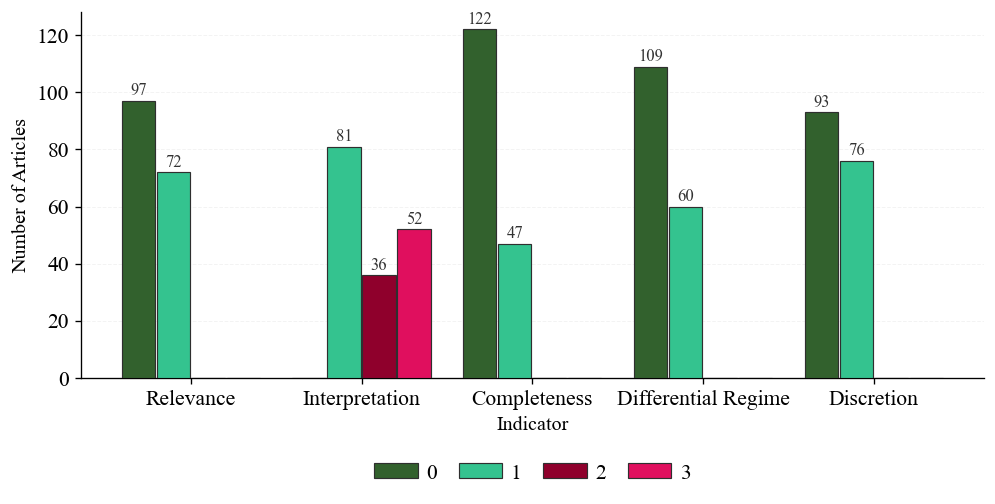

Saved files:
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\distribution\paper_distribution_articles_by_class.png
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\distribution\paper_distribution_articles_by_class.svg
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\distribution\paper_distribution_articles_by_class.pdf


In [19]:
fig, ax = plt.subplots(figsize=FIGSIZE)

x = np.arange(len(indicators))
n_labels = max(len(label_values), 1)
bar_width = min(0.82 / n_labels, 0.26)
offsets = (np.arange(n_labels) - (n_labels - 1) / 2.0) * bar_width

for i, lab in enumerate(label_values):
    vals = [
        int(count_df.loc[(count_df["indicator"] == c) & (count_df["class_value"] == lab), "count"].sum())
        for c in indicators
    ]

    color = CLASS_COLOR.get(lab, FALLBACK_COLORS[i % len(FALLBACK_COLORS)])
    bars = ax.bar(
        x + offsets[i],
        vals,
        width=bar_width * 0.95,
        label=str(lab),
        color=color,
        edgecolor="#2F2F2F",
        linewidth=0.7,
        zorder=3,
    )

    for b in bars:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x() + b.get_width()/2, h + 0.6, f"{int(h)}", ha="center", va="bottom", fontsize=10, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels([DISPLAY_NAME[c] for c in indicators], rotation=0, ha="center")
ax.set_xlabel("Indicator")
ax.set_ylabel("Number of Articles")

ax.grid(axis="y", alpha=0.14, linestyle="--", linewidth=0.6, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = ax.legend(
    title=None,
    frameon=False,
    ncol=min(len(label_values), 4),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    columnspacing=1.0,
    handletextpad=0.4,
)

fig.tight_layout(rect=[0.0, 0.08, 1.0, 1.0])

out_png = OUTPUT_DIR / f"{EXPORT_STEM}.png"
out_svg = OUTPUT_DIR / f"{EXPORT_STEM}.svg"
out_pdf = OUTPUT_DIR / f"{EXPORT_STEM}.pdf"

fig.savefig(out_png, dpi=EXPORT_DPI, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved files:")
print("-", out_png)
print("-", out_svg)
print("-", out_pdf)


## 5) Metadata


In [20]:
meta = pd.DataFrame([
    {
        "data_file": str(DATA_FILE),
        "rows_input": int(len(df)),
        "indicators": "; ".join(DISPLAY_NAME[c] for c in TARGET_COLUMNS),
        "class_values": "; ".join(str(v) for v in label_values),
        "export_stem": EXPORT_STEM,
    }
])

meta_path = OUTPUT_DIR / "paper_distribution_articles_by_class__metadata.csv"
count_path = OUTPUT_DIR / "paper_distribution_articles_by_class__counts.csv"

meta.to_csv(meta_path, index=False)
count_df.to_csv(count_path, index=False)

print("Saved metadata:", meta_path)
print("Saved counts:", count_path)
meta


Saved metadata: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\distribution\paper_distribution_articles_by_class__metadata.csv
Saved counts: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\distribution\paper_distribution_articles_by_class__counts.csv


,data_file,rows_input,indicators,class_values,export_stem
0,C:\Users\57305\OneDrive - Universidad Nacional...,169,Relevance; Interpretation; Completeness; Diffe...,0; 1; 2; 3,paper_distribution_articles_by_class
